In [ ]:
import sys
import os
import pandas as pd
import json

# Add the project's root directory to the Python path
sys.path.append(pathlib.Path("../").resolve().as_posix())

from scripts.model.preprocessing import initialize_model, train_token_classification

In [ ]:
output_dir = "./testing/"
train_csv = "../data/homonymous_word_forms/processed/homonyms_for_model.csv"
eval_csv = None
model_name = "../models/NER_mudel_v2/"
no_progress = False
output_dir = "./NER_mudel_v2_homonym/"
only_target_token = True
dry_run = False

In [ ]:
train_df = pd.read_csv(train_csv)
eval_df = pd.read_csv(eval_csv) if eval_csv else None

# Read labels from the unique labels json
with open("../outputs/unique_labels_old.json", "r") as f:
    labels = json.load(f)


model_bundle = initialize_model(model_name, labels, no_progress_bars=no_progress)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [ ]:
model_bundle["training_args"]["num_train_epochs"] = 10
print(model_bundle["training_args"])

{'train_batch_size': 8, 'learning_rate': 5e-05, 'num_train_epochs': 10, 'use_cuda': True}


In [ ]:
res = train_token_classification(
    model=model_bundle["model"],
    tokenizer=model_bundle["tokenizer"],
    train_df=train_df,
    label_list=labels,
    output_dir=output_dir,
    eval_df=eval_df,
    num_train_epochs=model_bundle["training_args"]["num_train_epochs"],
    train_batch_size=model_bundle["training_args"]["train_batch_size"],
    learning_rate=model_bundle["training_args"]["learning_rate"],
    evaluate_during_training=False if eval_df is None else True,
    use_early_stopping=False,
    best_model_dir=os.path.join(output_dir, "best_model"),
    save_model_every_epoch=False,
    save_steps=-1,
    device=model_bundle["device"],
    silent=no_progress,
    only_target_token=only_target_token,
    dry_run=dry_run,
)

print("Training finished. Results:")
print(res)

Epoch 1/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/986 [00:00<?, ?it/s]

...

Epoch 8/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 9/10:   0%|          | 0/986 [00:00<?, ?it/s]

Epoch 10/10:   0%|          | 0/986 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training finished. Results:
{'training_stats': {'train_loss': [0.6211717944336266, 0.413860430521371, 0.2587044141106553, 0.20631116118128473, 0.119771385078826, 0.07008046526439111, 0.042348910176425024, 0.021459761261913436, 0.01655831312362437, 0.014105002008681262], 'eval_f1': []}, 'last_eval': None}


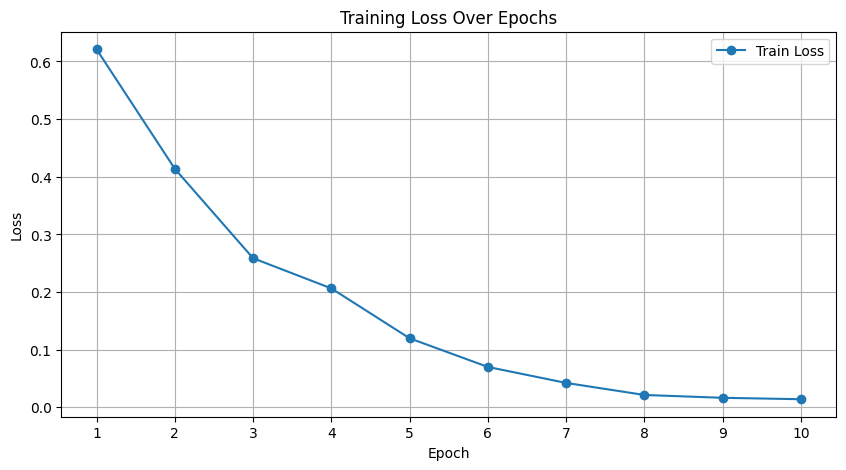

In [ ]:
import matplotlib.pyplot as plt

# Shift epoch numbers to start from 1 instead of 0
epochs = list(range(1, len(res["training_stats"]["train_loss"]) + 1))

# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(epochs, res["training_stats"]["train_loss"], label="Train Loss", marker="o")
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.grid()
plt.show()